# <font color="red"> Stage I: </font> Extraction of PCs from the FTIR data

In [ ]:
# Upload FTIR.xlsx
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd

ftir_data_raw = pd.read_excel('/content/FTIR.xlsx')
ftir_data=ftir_data_raw.iloc[1:,1:15].T

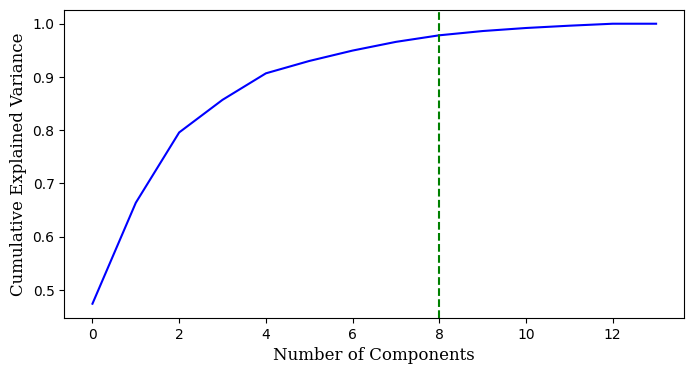

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

original_ftir_scaler=StandardScaler()
scaled_data=original_ftir_scaler.fit_transform(ftir_data)

pca=PCA()
pca.fit(scaled_data)
ftir_pca=pca.transform(scaled_data)

plt.figure(figsize=(8, 4))
plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    color='blue', alpha=1)
font = {'family': 'serif', 'weight': 'normal', 'size': 12}
plt.xlabel("Number of Components", fontdict=font)
plt.ylabel("Cumulative Explained Variance", fontdict=font)
plt.axvline(8, color="g", linestyle="--")
plt.savefig("cumulative_variance.png", format='png', dpi=600)
plt.show()

In [ ]:
sum=0
for i in range (8):
  sum+=pca.explained_variance_ratio_[i]
sum

np.float64(0.9659196241690984)

In [ ]:
pca=PCA(n_components=8)
pca.fit(scaled_data)
ftir_pca=pca.transform(scaled_data)

In [ ]:
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_
wights=pca.explained_variance_ratio_
df = pd.DataFrame(ftir_pca)
df.to_excel("ftir_pca.xlsx", index=False, header=False)

In [ ]:
reconstructed_ftir = np.dot(df.iloc[:,:8], eigenvectors)
#reconstructed_ftir =  reconstructed_ftir* original_ftir_scaler.scale_
reconstructed = original_ftir_scaler.inverse_transform(reconstructed_ftir)

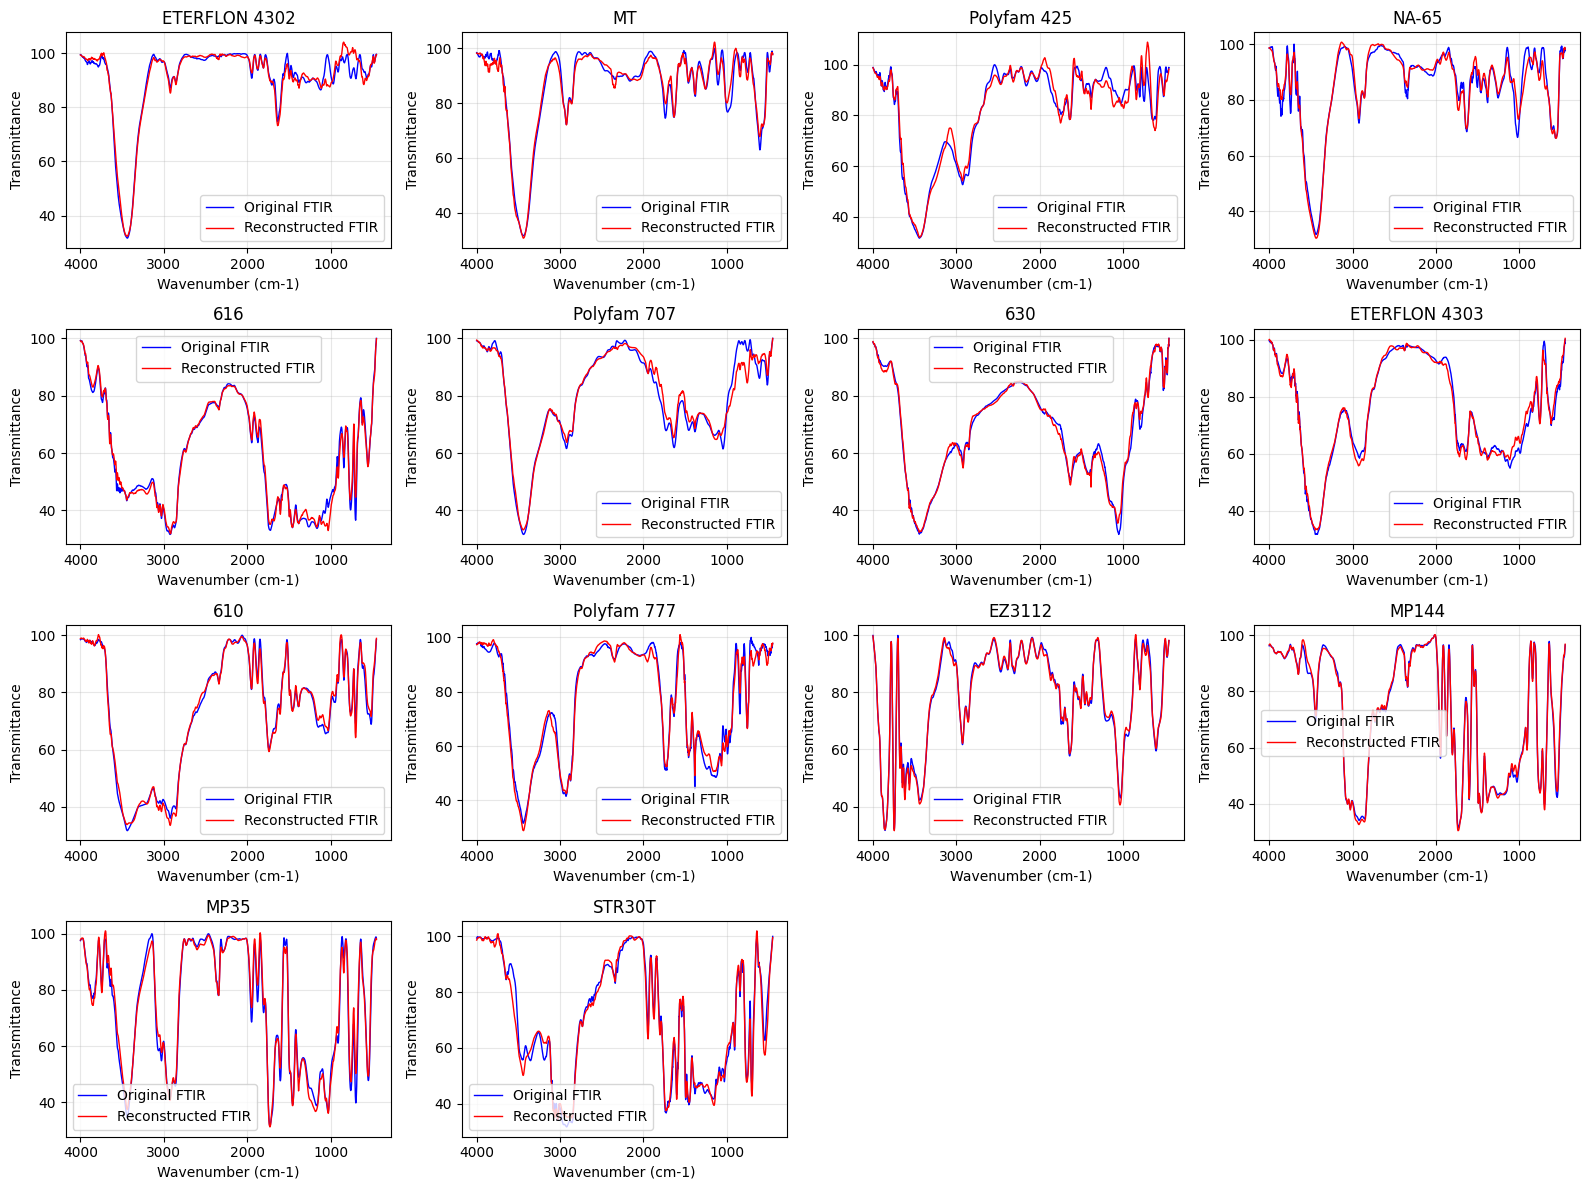

In [ ]:
# Create figure and subplots
fig, axes = plt.subplots(4, 4, figsize=(16, 12))

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Create the x-axis values from 4000 down to 450
x_values = np.linspace(4000, 450, 3551)

# Plot each of the 14 features
for i in range(14):
    ax = axes[i]

    # Plot both datasets for this feature
    ax.plot(x_values, ftir_data.to_numpy()[i], 'b-', label='Original FTIR', alpha=1, linewidth=1)
    ax.plot(x_values, reconstructed[i], 'r-', label='Reconstructed FTIR', alpha=1, linewidth=1)

    # Customize each subplot
    ax.set_title(f'{str(ftir_data_raw.T.iloc[i+1, 0]).replace(".0", "")}')
    ax.set_xlabel('Wavenumber (cm-1)')
    ax.set_ylabel('Transmittance')
    ax.legend()
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)

# Hide the last 2 empty subplots (since we only have 14 features in 4x4 grid)
for i in range(14, 16):
    axes[i].set_visible(False)

# Adjust layout and display
plt.tight_layout()
plt.savefig("measured_reconstructed_ftir.png", format='png', dpi=600)
plt.show()

# <font color=red> Stage II: </font> Modelling of PCA transformed FTIR data with ANN

In [ ]:
# Upload DE_DL_AL.xlsx
from google.colab import files
uploaded = files.upload()

Saving DE_DL_AL.xlsx to DE_DL_AL.xlsx


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import random

# Set all seeds for maximum reproducibility
seed = 10

# Set environment variables
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'  # For GPU determinism

# Set seeds for all libraries
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Configure TensorFlow for deterministic operations
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

# For GPU: Use only CPU if determinism is critical
# Uncomment the next line to force CPU usage for complete determinism
tf.config.set_visible_devices([], 'GPU')

# Load and preprocess the data
data1=pd.read_excel("ftir_pca.xlsx", header=None)
data2=pd.read_excel("DE_DL_AL.xlsx")

# <p><b><font color=red> Objective Selection: </font>for delta E* and delta L*, respectively assign 2 and 3 to the coloumn parameter. </b>

In [ ]:
column=3 # for delta E* and delta L*, respectively, assign 2 and 3 to the coloumn parameter

# Select the first PCs
X = data1.iloc[:,:8]
y = data2.iloc[:,column]

# Check the shape to confirm the selection
print(X.shape)
print(y.shape)

# Standardize features and target
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Split data into training and test sets
#X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=seed)

# Find indices of min and max y values
min_index = np.argmin(y)
max_index = np.argmax(y)

# Create test set
X_test = X_scaled[[min_index, max_index]]
y_test = y[[min_index, max_index]]

# Create train set by excluding those indices
train_indices = [i for i in range(len(y)) if i not in [min_index, max_index]]
X_train = X_scaled[train_indices]
y_train = y[train_indices]

input_shape = X_train.shape[1],

print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}, Input shape: {input_shape}")

(14, 8)
(14,)
Training shape: (12, 8), Test shape: (2, 8), Input shape: (8,)


Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - loss: 882.5395 - val_loss: 751.5899
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 813.3091 - val_loss: 732.7600
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 762.3110 - val_loss: 709.3600
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 665.5539 - val_loss: 667.9904
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 510.7168 - val_loss: 593.2223
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 332.2890 - val_loss: 598.6893
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 442.1924 - val_loss: 471.2380
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 104.3307 - val_loss: 337.5628
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 114.4104 - val_loss: 384.1596
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 159.2936 - val_loss: 356.8833
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 233.4636 - val_loss: 358.9076
Epoch 12/200
2/2 ━━━━━━━━━━━━

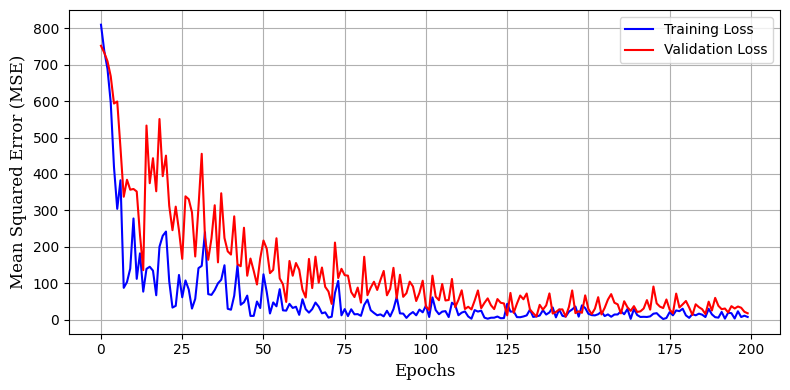

In [ ]:
from tensorflow.keras.optimizers import SGD

def create_model():
    model = Sequential([
        Input(shape=(input_shape)),
        Dense(100, activation="swish", kernel_initializer=tf.keras.initializers.glorot_uniform(seed=seed)),
        Dropout(0.5, seed=seed),
        Dense(100, activation='swish', kernel_initializer=tf.keras.initializers.glorot_uniform(seed=seed)),
        Dropout(0.1, seed=seed),
        Dense(1, kernel_initializer=tf.keras.initializers.glorot_uniform(seed=seed))
    ])

    # Use a deterministic optimizer
    optimizer = SGD(learning_rate=0.004)

    model.compile(optimizer=optimizer, loss='mse')
    return model

# Create and train the model
model = create_model()

# Train with deterministic settings
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=5,
    validation_split=0.2,
    verbose=1,
    shuffle=False  # Important: disable shuffling for reproducibility
)

# Evaluate the model
nn_predictions = model.predict(X_test, verbose=0)
nn_mse = mean_squared_error(y_test, nn_predictions)
nn_r2 = r2_score(y_test, nn_predictions)

print(f"MSE with Neural Network: {nn_mse:.6f}")
print(f"R² with Neural Network: {nn_r2:.6f}")

# Save model weights with correct naming convention
model.save_weights('model_weights.weights.h5')
print("Model weights saved as 'model_weights.weights.h5'")

import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(8, 4))
font = {'family': 'serif', 'weight': 'normal', 'size': 12}

plt.plot(history.history['loss'], 'b-', label='Training Loss')
plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
plt.xlabel('Epochs', fontdict=font)
plt.ylabel('Mean Squared Error (MSE)', fontdict=font)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("valid_train_loss.png", format='png', dpi=600)

plt.show()

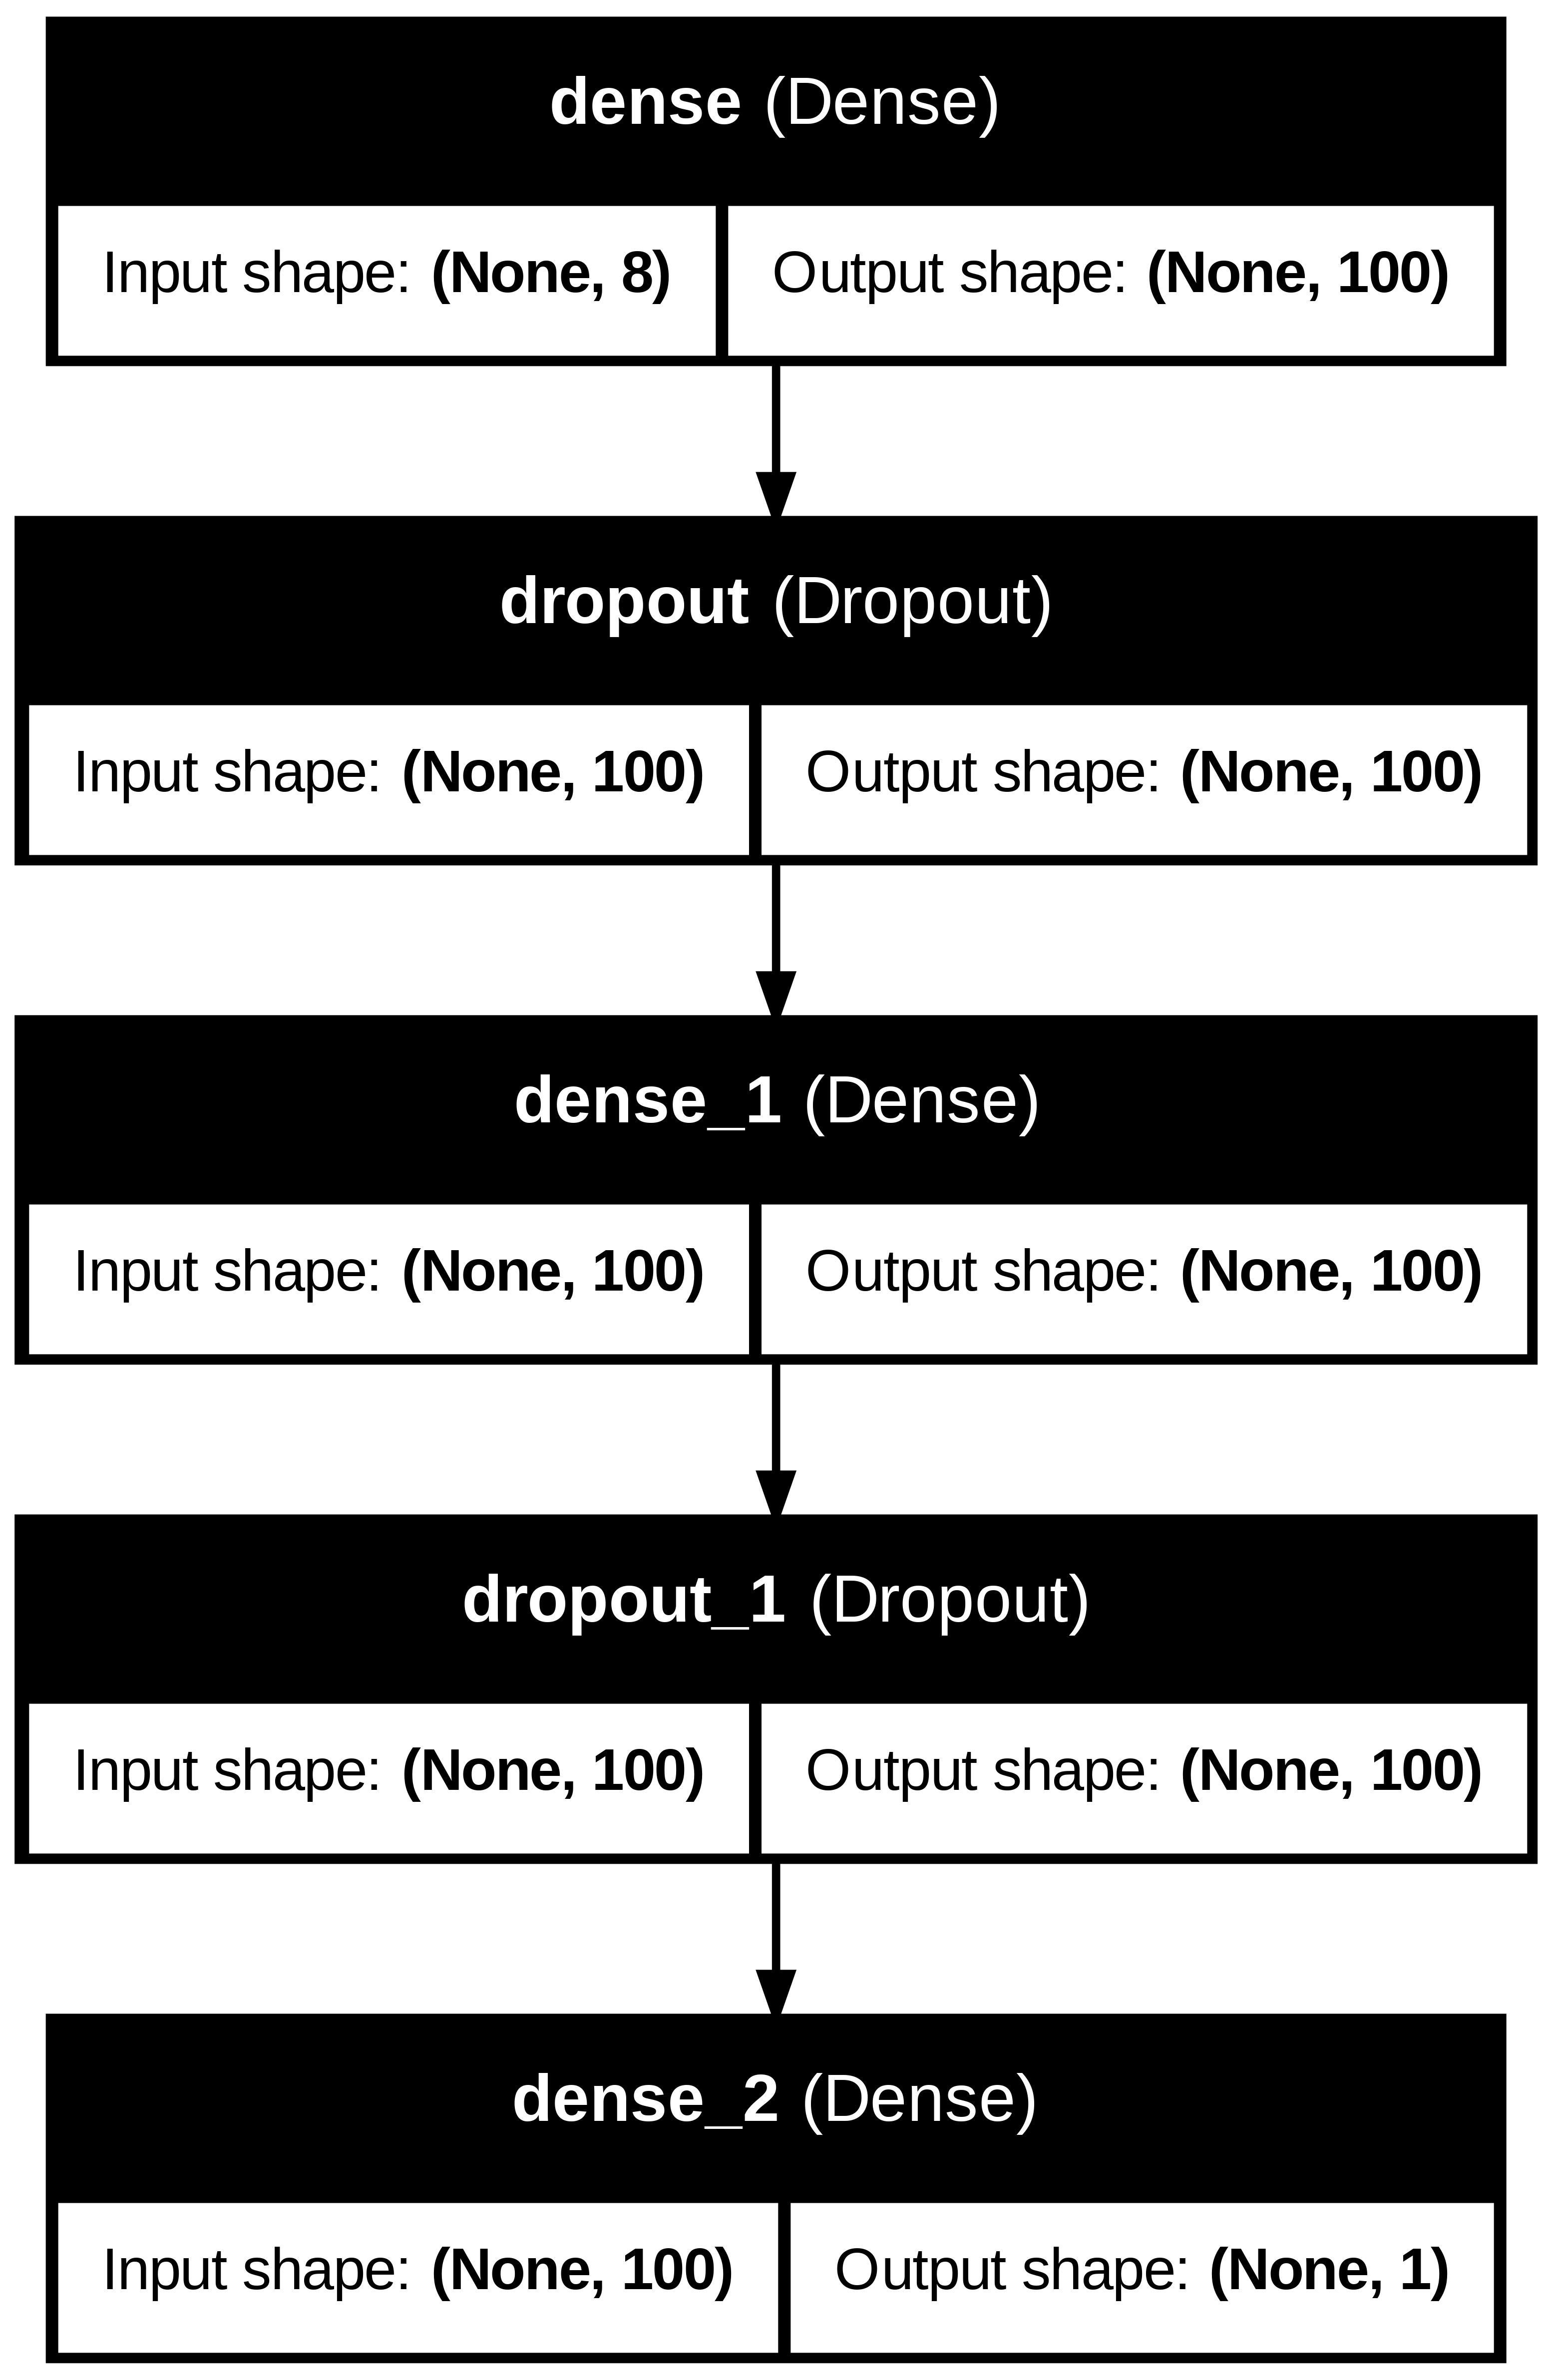

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model,
           to_file='model_architecture.png',
           show_shapes=True,
           show_layer_names=True,
           rankdir='TB',  # TB: top to bottom, LR: left to right
           expand_nested=True,
           dpi=600)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


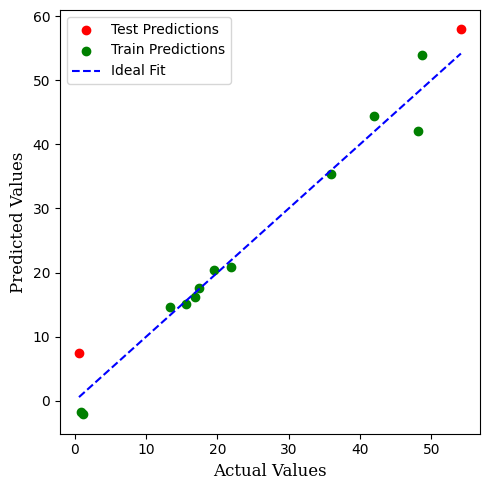

In [ ]:
# Visualize actual vs predicted values
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
font = {'family': 'serif', 'weight': 'normal', 'size': 12}
plt.scatter(
    y_test,
    nn_predictions,
    color='red', alpha=1, label='Test Predictions'
)
plt.scatter(
    y_train,
    model.predict(X_train),
    color='green', alpha=1, label='Train Predictions'
)

plt.plot(
    [min(y), max(y)],
    [min(y), max(y)],
    color='blue', linestyle='--', label='Ideal Fit'
)
plt.xlabel("Actual Values", fontdict=font)
plt.ylabel("Predicted Values", fontdict=font)
plt.legend()
plt.tight_layout()
plt.savefig(f"regression_plot_{column}.png", format='png', dpi=600)
plt.show()

# <font color=red> Stage III: </font> Prediction of FTIR data for a given delta L*

<b> Finding X <font color=red>(features: components of PCA)</font> for y=0.4 and y=60 <font color=red>(objective: delta L*) </font></b>

In [ ]:
import tensorflow as tf
import numpy as np

def find_x_for_target_y(model, target_y, initial_guess=None, learning_rate=0.01, iterations=2000):
    """
    Find X that produces the target y value using gradient descent with gradient tape
    """
    if initial_guess is None:
        # Use the mean of training data as initial guess
        initial_guess = np.mean(X_train, axis=0)

    # Convert to TensorFlow variable for gradient computation
    x_var = tf.Variable(initial_guess.reshape(1, -1), dtype=tf.float32)

    # Use Adam optimizer
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    for i in range(iterations):
        with tf.GradientTape() as tape:
            # Make prediction
            prediction = model(x_var)
            # Calculate loss: (prediction - target_y)^2
            loss = tf.square(prediction - target_y)

        # Compute gradients
        gradients = tape.gradient(loss, x_var)

        # Apply gradients
        optimizer.apply_gradients(zip([gradients], [x_var]))

        if i % 200 == 0 or i == iterations - 1:
            current_loss = loss.numpy()[0][0]
            current_pred = prediction.numpy()[0][0]
            print(f"Iteration {i}: Loss = {current_loss:.6f}, Current y = {current_pred:.4f}")

    optimized_x = x_var.numpy()[0]
    final_prediction = model(x_var).numpy()[0][0]

    print(f"\nTarget y: {target_y}")
    print(f"Achieved y: {final_prediction:.6f}")
    print(f"Optimized X: {optimized_x}")

    return optimized_x

# Find X for y = 0.4
print("Finding X for y = 0.4:")
x_for_y4 = find_x_for_target_y(model, 0.4)

print("\n" + "="*50 + "\n")

# Find X for y = 60
print("Finding X for y = 60:")
x_for_y60 = find_x_for_target_y(model, 60.0)

Finding X for y = 0.4:
Iteration 0: Loss = 381.743591, Current y = 19.9383
Iteration 200: Loss = 0.542382, Current y = 1.1365
Iteration 400: Loss = 0.004558, Current y = 0.4675
Iteration 600: Loss = 0.000010, Current y = 0.4031
Iteration 800: Loss = 0.000000, Current y = 0.4001
Iteration 1000: Loss = 0.000000, Current y = 0.4000
Iteration 1200: Loss = 0.000000, Current y = 0.4000
Iteration 1400: Loss = 0.000000, Current y = 0.4000
Iteration 1600: Loss = 0.000000, Current y = 0.4000
Iteration 1800: Loss = 0.000000, Current y = 0.4000
Iteration 1999: Loss = 0.000000, Current y = 0.4000

Target y: 0.4
Achieved y: 0.400006
Optimized X: [-0.69771886  0.613386    0.41892892  0.5272106   0.8711238  -0.58848757
  0.6509017   0.6244388 ]


Finding X for y = 60:
Iteration 0: Loss = 1604.943115, Current y = 19.9383
Iteration 200: Loss = 0.000334, Current y = 59.9817
Iteration 400: Loss = 0.000000, Current y = 60.0000
Iteration 600: Loss = 0.000000, Current y = 60.0000
Iteration 800: Loss = 0.0000

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def reconstruct_ftir_complete(pca_components, pca_object, original_ftir_scaler):

    # Ensure proper shape
    pca_components = pca_components.reshape(1, -1)

    # 1. Reverse PCA transformation
    reconstructed_std = np.dot(pca_components, eigenvectors)

    # 2. Reverse the standardization that was applied to original FTIR data
    reconstructed =  reconstructed_std* original_ftir_scaler.scale_
    reconstructed = original_ftir_scaler.inverse_transform(reconstructed)

    return reconstructed

# Reconstruct FTIR data with proper standardization reversal
ftir_y4 = reconstruct_ftir_complete(x_for_y4, pca, original_ftir_scaler)
ftir_y60 = reconstruct_ftir_complete(x_for_y60, pca, original_ftir_scaler)

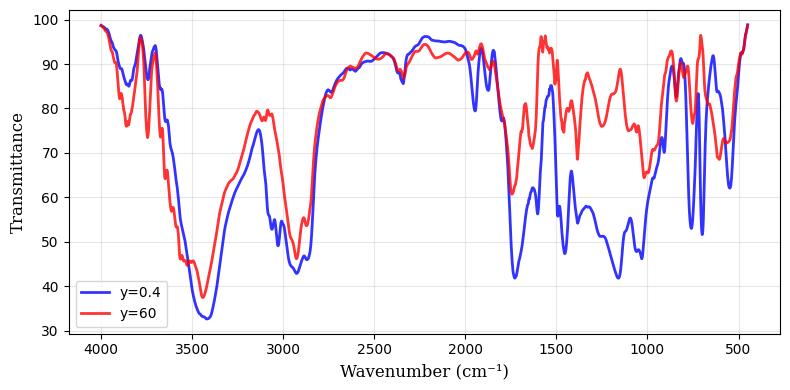

In [ ]:
def plot_reconstructed_spectra(ftir_y5, ftir_y60, wavenumbers):

    plt.figure(figsize=(8, 4))
    font = {'family': 'serif', 'weight': 'normal', 'size': 12}

    if wavenumbers is not None:
        plt.plot(wavenumbers, ftir_y4.flatten(), 'b-', label='y=0.4', linewidth=2, alpha=0.8)
        plt.plot(wavenumbers, ftir_y60.flatten(), 'r-', label='y=60', linewidth=2, alpha=0.8)
        plt.xlabel('Wavenumber (cm⁻¹)', fontdict=font)
        plt.gca().invert_xaxis()  # FTIR convention
    else:
        # Create dummy wavenumbers if not provided
        x_axis = np.arange(ftir_y4.shape[1])
        plt.plot(x_axis, ftir_y4.flatten(), 'b-', label='y=0.4', linewidth=2, alpha=0.8)
        plt.plot(x_axis, ftir_y60.flatten(), 'r-', label='y=60', linewidth=2, alpha=0.8)
        plt.xlabel('Spectral Index')

    plt.ylabel('Transmittance', fontdict=font)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("reconstructed_ftir_spectra.png", format='png', dpi=600)
    plt.show()

df=pd.read_excel("FTIR.xlsx")
wavenumbers=df.iloc[1:,0].to_numpy()

# Plot the spectra
plot_reconstructed_spectra(ftir_y4, ftir_y60, wavenumbers)